# 🏠 House Price Prediction with Neural Networks

This notebook demonstrates how to build a **neural network** to predict house prices using a synthetic housing dataset from Kaggle.

## What we'll learn:
- **Data loading and preprocessing** from Kaggle
- **Exploratory data analysis** to understand the features
- **Building a neural network** with PyTorch
- **Training with regularization** (Dropout + L2)
- **Evaluating model performance** on unseen test data
- **Visualizing results** and understanding predictions

---

## 📦 Step 0: Install required packages and import libraries

Before we begin, we need to install the tools (libraries) that our code depends on:

| Library | Purpose |
|---------|----------|
| `torch` | PyTorch — the deep learning framework we use to build and train the neural network |
| `scikit-learn` | Provides utilities for data splitting and scaling |
| `kagglehub` | Downloads datasets directly from Kaggle |
| `pandas` | Works with tabular data (like an Excel spreadsheet) |
| `numpy` | Fast numerical operations on arrays |
| `matplotlib` / `seaborn` | Creating static charts and visualizations |

**Run this cell once** — it may take a minute to install everything.

In [2]:
# ============================================
# INSTALLATION and IMPORT — Run this first!
# ============================================
# The "%pip" magic command installs packages
# directly from within a Jupyter notebook.

%pip install torch scikit-learn kagglehub pandas numpy matplotlib seaborn --quiet

!wget https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/week1/cx3-intro-to-nns/utils.py

print("✅ All packages installed successfully!")

import torch                             # Core PyTorch library
import torch.nn as nn                    # Neural network building blocks

# --- Data handling ---
import numpy as np                       # Numerical arrays and math
import pandas as pd                      # DataFrames (tabular data)
import kagglehub                         # Download datasets from Kaggle
import os                                # File-system utilities

# --- Machine learning utilities ---
from sklearn.model_selection import train_test_split  # Split data
from sklearn.preprocessing import StandardScaler      # Scale data

# --- Visualization ---
import matplotlib.pyplot as plt          # Static plots
import seaborn as sns                    # Statistical plots

# Apply a clean visual style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

--2026-04-14 10:46:46--  https://raw.githubusercontent.com/eth-bmai-fs26/coding-exercises/week1/cx3-intro-to-nns/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23832 (23K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]  23.27K  --.-KB/s    in 0.001s  

2026-04-14 10:46:46 (15.3 MB/s) - ‘utils.py’ saved [23832/23832]

✅ All packages installed successfully!
✅ All libraries imported successfully!


---

# 📊 1. Data Loading & Exploration

## About the Dataset

We use a **synthetic (computer-generated) house price dataset** from Kaggle containing **10,000 houses**.

Each house is described by these features:

| Feature | Description |
|---------|------------|
| `square_feet` | Size of the house in square feet |
| `num_rooms` | Number of rooms |
| `age` | Age of the house in years |
| `distance_to_city(km)` | Distance from city center in km |
| `price` | The house price — **this is what we want to predict!** |

The code below **automatically downloads** the dataset from Kaggle using `kagglehub`.

In [3]:
# ============================================
# DOWNLOAD DATASET FROM KAGGLE
# ============================================
# kagglehub.dataset_download() fetches the dataset
# and caches it locally so it won't re-download next time.

print("📥 Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download(
    'muhamedumarjamil/house-price-prediction-dataset'
)
print(f"✅ Dataset downloaded to: {dataset_path}")

📥 Downloading dataset from Kaggle...


100%|██████████| 292k/292k [00:00<00:00, 48.0MB/s]

Extracting files...
✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/muhamedumarjamil/house-price-prediction-dataset/versions/1


### Loading the CSV into a DataFrame

A **DataFrame** (from the `pandas` library) is essentially a table with labelled columns — very similar to a spreadsheet. We use `pd.read_csv()` to read the CSV file that was just downloaded.

In [4]:
# ============================================
# LOAD CSV INTO A PANDAS DATAFRAME
# ============================================

csv_file = os.path.join(dataset_path, 'house_prices_dataset.csv')
df = pd.read_csv(csv_file)

print(f"✅ Dataset loaded!")
print(f"   Rows (houses):    {len(df)}")
print(f"   Columns (features): {len(df.columns)}")
print(f"   Column names: {list(df.columns)}")

✅ Dataset loaded!
   Rows (houses):    10000
   Columns (features): 5
   Column names: ['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price']


### Visual exploration

Before building a model, it is always a good idea to **visualize** the data. We create four plots:

1. **Price distribution** — is it symmetric? skewed? are there outliers?
2. **Feature correlations** — which features are most/least related to price?
3. **Size vs Price** scatter — the single strongest predictor.
4. **Age vs Price** scatter — does age make a house cheaper or more expensive?

/tmp/ipykernel_6437/2360482763.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2360482763.py:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2360482763.py:41: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2360482763.py:41: UserWarning: Glyph 128368 (\N{MANTELPIECE CLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-pack

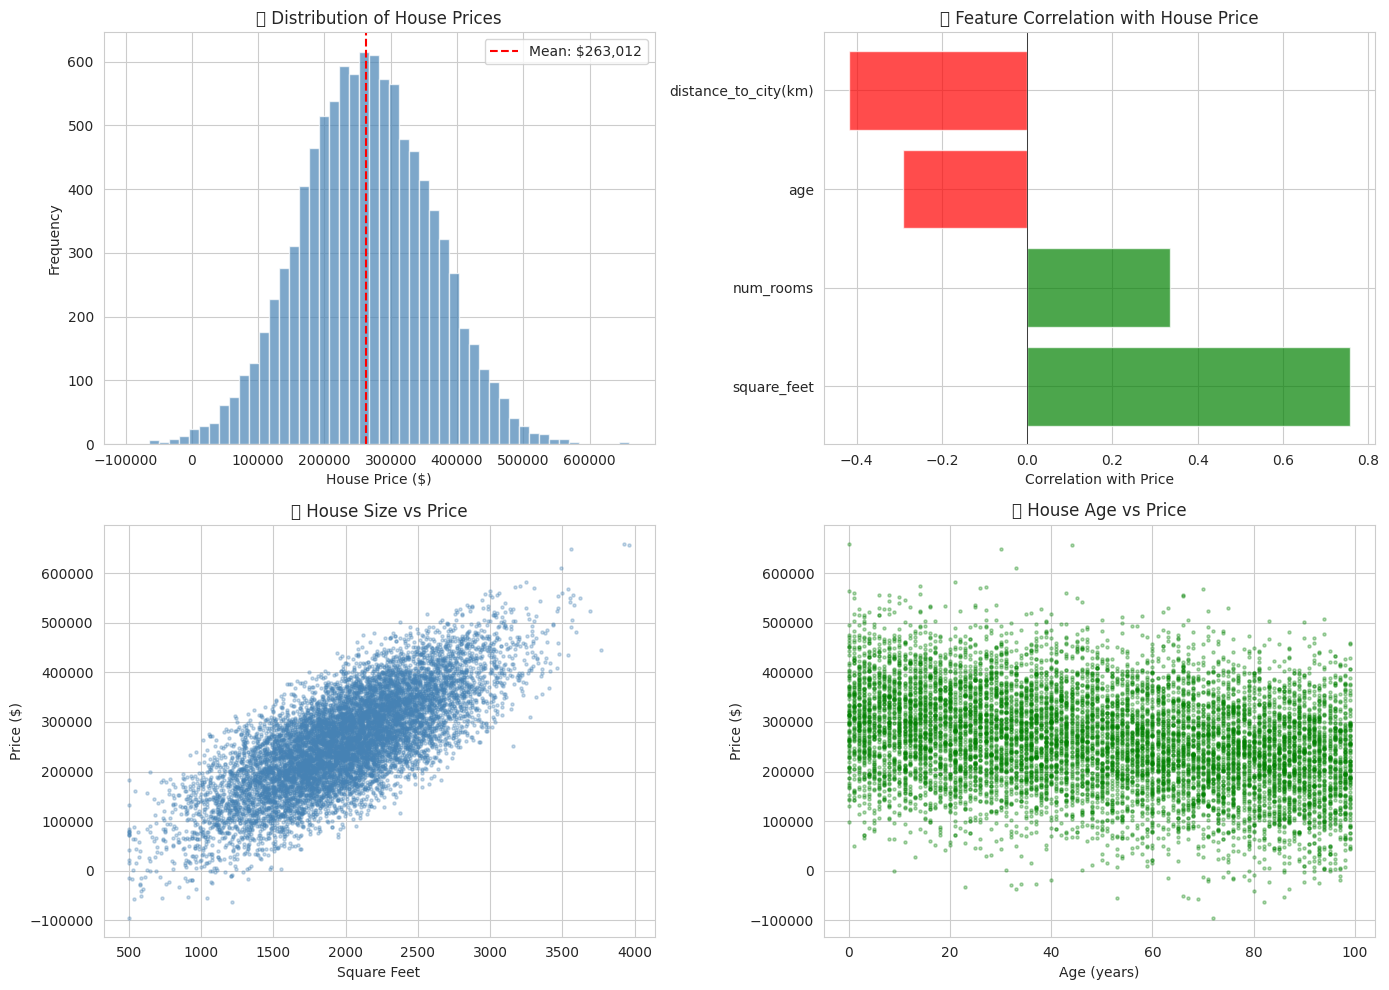

In [5]:
# ============================================
# DATA VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Distribution of house prices ---
axes[0, 0].hist(df['price'], bins=50, color='steelblue',
                edgecolor='white', alpha=0.7)
axes[0, 0].set_xlabel('House Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('📊 Distribution of House Prices')
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--',
                    label=f'Mean: ${df["price"].mean():,.0f}')
axes[0, 0].legend()

# --- 2. Feature correlation with price ---
# We only correlate numeric feature columns (exclude 'price' itself)
feature_cols = [c for c in df.columns if c != 'price']
correlations = [df[c].corr(df['price']) for c in feature_cols]
colors = ['green' if c > 0 else 'red' for c in correlations]
axes[0, 1].barh(feature_cols, correlations, color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Correlation with Price')
axes[0, 1].set_title('📈 Feature Correlation with House Price')
axes[0, 1].axvline(0, color='black', linewidth=0.5)

# --- 3. Square Feet vs Price ---
axes[1, 0].scatter(df['square_feet'], df['price'], alpha=0.3, s=5,
                   c='steelblue')
axes[1, 0].set_xlabel('Square Feet')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].set_title('📐 House Size vs Price')

# --- 4. Age vs Price ---
axes[1, 1].scatter(df['age'], df['price'], alpha=0.3, s=5,
                   c='green')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].set_title('🕰️ House Age vs Price')

plt.tight_layout()
plt.show()

### 🎯🎯🎯 YOUR TASK - 🧹 Data Cleaning 🎯🎯🎯🎯🎯🎯

If you look at the price distribution above, you can notice something weird.

- There are some outliers at the right tail of the Gaussian curve
- Some houses have negative price

Before we proceed, we need to clean the data by removing **extreme outliers** and data that does not make sense. There are multiple ways in which we can do so; for example, we can use log-space to identify and remove houses with prices more than 5 standard deviations from the mean.

In [6]:
# ============================================
# DATA CLEANING
# ============================================

print(f"📊 Original dataset size: {len(df)} samples")

# 🎯🎯🎯 TODO 🎯🎯🎯 - Remove houses with negative price from the dataset.
# Save it in a variable with the same name!
...
print(f"   After removing negative price: {len(df)} samples")

# 🎯🎯🎯 TODO 🎯🎯🎯 - Remove extreme outliers using log-space (±5 std)
# This helps the model learn better by removing houses with unusual prices
# Save it in a variable with the same name!
df = ...

print(f"   After removing outliers: {len(df)} samples")
print(f"✅ Data cleaning complete!")

📊 Original dataset size: 10000 samples
   After removing negative price: 9962 samples
   After removing outliers: 9925 samples
✅ Data cleaning complete!


---

# 🔧 2. Data Preparation

Raw data cannot be fed directly into a neural network — we need three preparation steps:

1. **Separate features and target** — the model receives the features as input and tries to predict the target (price).
2. **Split** the data into training, validation, and test sets.
3. **Scale** (standardize) the values so all features live on a similar numeric range.

## Why three sets?

| Set | % of data | Role |
|-----|-----------|------|
| Training | 80% | The model **learns** from this data |
| Validation | 10% | Used to **monitor** training and detect overfitting |
| Test | 10% | **Final evaluation** on data the model has never seen |

### 2a. Separate features and target (with log transformation)

We pull the **input features** (square_feet, num_rooms, age, distance_to_city) into one array and the **target** (price) into another.

**Why log-transform prices?**

House prices are often **right-skewed** — there are many affordable houses and fewer expensive ones. Training on raw prices means:
- The model focuses on getting expensive houses right (large absolute errors)
- Percentage errors on cheap houses can be huge

Log transformation:
- Compresses the price range
- Makes the model learn **relative** (percentage) errors
- Works well because $\exp(\log(a) - \log(b)) = \frac{a}{b}$ (ratio prediction)

In [7]:
# ============================================
# SEPARATE FEATURES AND TARGET (with log transformation)
# ============================================

# Feature columns — everything except 'price' and 'log_price'
feature_columns = [c for c in df.columns if c not in ['price', 'log_price']]

# .values converts a DataFrame column (or selection) into a NumPy array
features = df[feature_columns].values          # shape: (N, 4)

# Log transform the prices for training (neural networks learn better with log prices)
# This helps with skewed price distributions and makes relative errors more uniform
log_prices = np.log(df['price'].values).reshape(-1, 1)   # shape: (N, 1)

# Keep original prices for final evaluation (to compute metrics in dollars)
original_prices = df['price'].values.reshape(-1, 1)      # shape: (N, 1)

print(f"Number of samples:  {len(log_prices)}")
print(f"Number of features: {features.shape[1]}")
print(f"Feature names:      {feature_columns}")
print(f"\n📊 Price statistics:")
print(f"   Original range: ${original_prices.min():,.0f} - ${original_prices.max():,.0f}")
print(f"   Log price range: {log_prices.min():.2f} - {log_prices.max():.2f}")

Number of samples:  9925
Number of features: 4
Feature names:      ['square_feet', 'num_rooms', 'age', 'distance_to_city(km)']

📊 Price statistics:
   Original range: $22,210 - $660,168
   Log price range: 10.01 - 13.40


### 2b. 🎯🎯🎯 YOUR TASK - Split the data 🎯🎯🎯

`train_test_split` from scikit-learn randomly shuffles the data and divides it. We call it **twice** to create three sets from the original data:

```
Full data  ──▶  80% Training  +  20% Temp
         Temp  ──▶  50% Validation  +  50% Test
```

This gives us an **80/10/10** split (training / validation / test).

Setting `random_state=42` makes the split **reproducible** — you get the same split every time you run the cell.

In [8]:
# ============================================
# SPLIT THE DATA INTO TRAIN / VAL / TEST
# ============================================

# 🎯🎯🎯 TODO 🎯🎯🎯
# First split: 80% training, 20% temporary
# We split features, log_prices (for training), and original_prices (for evaluation)
(train_features, temp_features,
 train_log_prices, temp_log_prices,
 train_orig_prices, temp_orig_prices) = ...

# 🎯🎯🎯 TODO 🎯🎯🎯
# Second split: 50/50 on the temporary set → 10% val + 10% test
(val_features, test_features,
 val_log_prices, test_log_prices,
 val_orig_prices, test_orig_prices) = ...

print(f"Training samples:   {len(train_log_prices)}")
print(f"Validation samples: {len(val_log_prices)}")
print(f"Test samples:       {len(test_log_prices)}")

Training samples:   7940
Validation samples: 992
Test samples:       993


### 2c. 🎯🎯🎯 YOUR TASK - Scale (standardize) the features 🎯🎯🎯

Neural networks learn much faster when all input values are on a **similar scale**.

**Standardization** transforms every feature column so that it has:
- **mean = 0**
- **standard deviation = 1**

The formula for each value $x$ is:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

where $\mu$ is the column mean and $\sigma$ is the standard deviation.

> ⚠️ **Important:** we call `.fit_transform()` on the **training set only**, then `.transform()` on validation and test sets. This prevents *data leakage* — the model must not see statistics from data it will be evaluated on. Concretely, `.fit_transform()` computes $\mu$ and $\sigma$ from the training data and immediately applies the scaling formula above to produce the standardized values.

> 💡 **Note:** We only scale the **features**, NOT the log prices. Since we use log-transformed prices, they're already in a reasonable numeric range, and we need to convert predictions back using `np.exp()` during evaluation.

In [9]:
# ============================================
# SCALE THE DATA
# ============================================

# Create scaler for features ONLY
# Note: We do NOT scale log_prices - they are already in a good range
# and we need to convert predictions back using np.exp()
feature_scaler = StandardScaler()

# Fit on training data, then transform all three sets
# 🎯🎯🎯 TODO 🎯🎯🎯 - Scale the features using the standard scaler
train_features = ...
val_features   = ...
test_features  = ...

# Log prices are NOT scaled - they remain as-is
# This makes it easier to convert predictions back to real prices

print("✅ Features scaled — all feature values now have mean ≈ 0 and std ≈ 1.")
print("   Log prices are NOT scaled (will use np.exp() to convert back)")

✅ Features scaled — all feature values now have mean ≈ 0 and std ≈ 1.
   Log prices are NOT scaled (will use np.exp() to convert back)


### 2d. Convert to PyTorch tensors

PyTorch works with its own data type called a **tensor**, which is similar to a NumPy array but can also run on a GPU for faster computation. We convert all our arrays now.

In [10]:
# ============================================
# CONVERT TO PYTORCH TENSORS
# ============================================

# Convert features to tensors
train_features_t = torch.tensor(train_features, dtype=torch.float32)
val_features_t   = torch.tensor(val_features,   dtype=torch.float32)
test_features_t  = torch.tensor(test_features,  dtype=torch.float32)

# Convert log prices to tensors (these are what we train on)
train_log_prices_t = torch.tensor(train_log_prices, dtype=torch.float32)
val_log_prices_t   = torch.tensor(val_log_prices,   dtype=torch.float32)
test_log_prices_t  = torch.tensor(test_log_prices,  dtype=torch.float32)

# Keep original prices as numpy arrays for final evaluation
# (they will be used to compute metrics in actual dollars)

print(f"Training tensor shapes:   features {train_features_t.shape}, log_prices {train_log_prices_t.shape}")
print(f"Validation tensor shapes: features {val_features_t.shape}, log_prices {val_log_prices_t.shape}")
print(f"Test tensor shapes:       features {test_features_t.shape}, log_prices {test_log_prices_t.shape}")

Training tensor shapes:   features torch.Size([7940, 4]), log_prices torch.Size([7940, 1])
Validation tensor shapes: features torch.Size([992, 4]), log_prices torch.Size([992, 1])
Test tensor shapes:       features torch.Size([993, 4]), log_prices torch.Size([993, 1])


---

# 3. 🎯🎯🎯 YOUR TASK 🎯🎯🎯 - 🧠 Neural Network Architecture

## What is a neural network?

A neural network is a series of **layers** of interconnected "neurons". Each layer takes numbers in, applies a weighted sum plus a non-linear function, and passes the result to the next layer. By adjusting the weights during training, the network learns to map inputs to the desired output. It learns the underlying patterns and features of the data through **repeated forward and backward passes** (epochs), progressively adjusting its weights to minimize prediction error.

## Our architecture

We use a **4-layer fully-connected network** with BatchNorm:

```
Input (4 features) → 128 → 128 → 64 → 1 (log price)
```

Here is a visual representation of the network structure (simplified):

```
  ┌───────────┐     ┌───────────┐     ┌───────────┐     ┌───────────┐     ┌──────────┐
  │  INPUT    │     │  LAYER 1  │     │  LAYER 2  │     │  LAYER 3  │     │  OUTPUT  │
  │ (4 feat.) │───▶│  128 neurons──▶│  128 neurons──▶│  64 neurons───▶│ 1 neuron │
  │           │     │           │     │           │     │           │     │          │
  │sq_feet    │     │ Linear    │     │ Linear    │     │ Linear    │     │ Linear   │
  │num_rooms  │     │ BatchNorm │     │ BatchNorm │     │ BatchNorm │     │ (no act.)│
  │age        │     │ ReLU      │     │ ReLU      │     │ ReLU      │     │          │
  │distance   │     │ Dropout(p)│     │ Dropout(p)│     │ Dropout(p/2)    │          │
  └───────────┘     └───────────┘     └───────────┘     └───────────┘     └──────────┘
```

Notice the pattern: each hidden layer follows the same **Linear → BatchNorm → ReLU → Dropout** structure. The final layer before the output uses **reduced dropout** (`p/2`) because we want the last hidden representation to be more stable before making the prediction. The **output layer** is a single `Linear` layer with **no activation function and no dropout** — since we are doing regression, we want the raw (unbounded) output value.

### Key components

| Component | What it does |
|-----------|-------------|
| `nn.Linear(in, out)` | A fully-connected layer: computes `out = weight × in + bias` |
| `nn.BatchNorm1d(n)` | Normalizes layer outputs for more stable training |
| `nn.ReLU()` | Activation function: keeps positive values, sets negatives to 0 |
| `nn.Dropout(p)` | During training, randomly sets a fraction `p` of neurons to 0 — this prevents **overfitting** |

### Why BatchNorm?

BatchNorm normalizes the inputs to each layer, which helps with:
- **Faster convergence** — allows using higher learning rates
- **Regularization** — adds slight noise during training
- **Stable gradients** — reduces internal covariate shift

### 💡 Example: Building a single hidden layer

Each hidden block in our model looks like this in PyTorch:

```python
# Example: one hidden layer block (input_size → 128 neurons)
nn.Linear(input_size, 128),   # Weighted sum + bias
nn.BatchNorm1d(128),          # Normalize outputs
nn.ReLU(),                    # Non-linear activation
nn.Dropout(0.2),              # Regularization (20% dropout)
```

Your task is building the **layers 2, 3, and 4** of our model (as shown in the table above).

In [11]:
# ============================================
# DEFINE THE NEURAL NETWORK MODEL
# ============================================

class HousePriceModel(nn.Module):
    """
    A neural network for house price prediction with BatchNorm.

    Architecture:
        Input → 128 → 128 → 64 → 1
        with BatchNorm, ReLU activations, and Dropout regularization.

    Improvements over the original:
        - BatchNorm for stable training
        - Wider layers for more capacity
        - Better dropout distribution
    """

    def __init__(self, n_features, dropout_rate=0.2):
        super().__init__()

        self.network = nn.Sequential(
            # Layer 1: input features → 128 neurons
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # 🎯🎯🎯 TODO 🎯🎯🎯
            # Layer 2: 128 → 128 neurons
            ...

            # 🎯🎯🎯 TODO 🎯🎯🎯
            # Layer 3: 128 → 64 neurons
            ...

            # 🎯🎯🎯 TODO 🎯🎯🎯
            # Output layer: 64 → 1 (predicted log price)
            # No activation and no dropout on the output layer.
            ...
        )

    def forward(self, x):
        """Forward pass: push input x through all layers."""
        return self.network(x)


# Instantiate the model
model = HousePriceModel(
    n_features=train_features_t.shape[1],  # 4 features
    dropout_rate=0.2
)

print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")

HousePriceModel(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

📊 Total parameters: 26,113


### Understanding the model summary

The printout above lists every layer in sequence. Each `Linear` layer shows its input and output dimensions. The total number of **trainable parameters** (weights + biases) across all layers determines the model's capacity to learn complex relationships.

### 🎨 Visualizing the Network Architecture with torchview

Let's use `torchview` to create a visual representation of our neural network's computational graph. This shows how data flows through each layer with tensor shapes at every step.

In [12]:
# ============================================
# INSTALL TORCHVIEW FOR VISUALIZATION
# ============================================
%pip install torchview --quiet

from torchview import draw_graph

print("✅ torchview installed and imported successfully!")

✅ torchview installed and imported successfully!


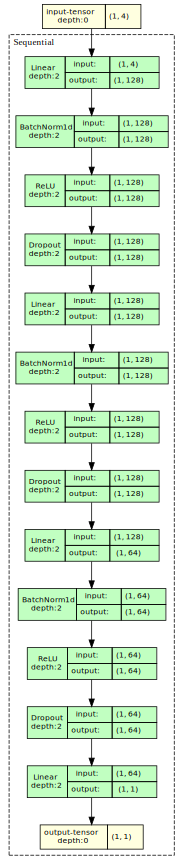

In [13]:
# ============================================
# VISUALIZE THE NETWORK ARCHITECTURE
# ============================================

# Create a sample input tensor with the correct shape
# (batch_size=1, n_features=4)
sample_input = torch.randn(1, 4)

# Generate the computational graph visualization
model_graph = draw_graph(
    model,
    input_data=sample_input,
    expand_nested=True,          # Show all layers including Sequential blocks
    depth=10,                    # Maximum depth to expand nested modules
    graph_name='HousePriceModel',
    save_graph=False,            # Display in notebook
    device='cpu'
)

# Display the graph
model_graph.visual_graph

---

# 4. 🎯🎯🎯 YOUR TASK 🎯🎯🎯 - 🏋️ Training the Model

Training means repeatedly:

1. **Forward pass** — the model makes predictions for all training houses.
2. **Loss computation** — we measure how wrong the predictions are (Mean Squared Error on log prices).
3. **Backward pass** — PyTorch calculates the gradient of the loss with respect to every weight.
4. **Optimizer step** — the optimizer adjusts the weights to reduce the loss.

One full cycle through the training set is called an **epoch**.

## Hyperparameters

| Hyperparameter | Value | Meaning |
|---------------|-------|---------|
| `learning_rate` | 0.001 | How big each weight update step is |
| `weight_decay` | 1e-4 | L2 regularization — penalizes large weights |
| `dropout_rate` | 0.2 | Fraction of neurons randomly disabled each step |
| `max_epochs` | 2000 | Maximum training loops (early stopping will likely stop earlier) |

## Additional Improvements

- **Learning Rate Scheduler**: Automatically reduces LR when validation loss plateaus
- **Early Stopping**: Stops training if no improvement for 100 epochs
- **Gradient Clipping**: Prevents exploding gradients (max_norm=1.0)

In [14]:
# ============================================
# SET UP LOSS FUNCTION AND OPTIMIZER
# ============================================

# MSELoss = Mean Squared Error: average of (prediction - actual)²
# 🎯🎯🎯 TODO 🎯🎯🎯
loss_function = ...

# Learning rate — controls step size during optimization
# 🎯🎯🎯 TODO 🎯🎯🎯
learning_rate = ...

# Weight decay — L2 regularization strength
# 🎯🎯🎯 TODO 🎯🎯🎯
weight_decay = ...

# Adam optimizer — a popular gradient-descent variant that adapts
# the learning rate for each parameter individually.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Learning rate scheduler — reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # Minimize validation loss
    factor=0.5,      # Reduce LR by half
    patience=50      # Wait 50 epochs before reducing
)

# Number of full passes over the training data
number_of_epochs = 2000

print(f"Loss function: {loss_function}")
print(f"Optimizer:     Adam (lr={learning_rate}, weight_decay={weight_decay})")
print(f"Scheduler:     ReduceLROnPlateau (factor=0.5, patience=50)")
print(f"Max epochs:    {number_of_epochs}")

Loss function: MSELoss()
Optimizer:     Adam (lr=0.001, weight_decay=0.0001)
Scheduler:     ReduceLROnPlateau (factor=0.5, patience=50)
Max epochs:    2000


### The training loop

Inside each epoch we do **two things**:

1. **Train** — `model.train()` activates dropout. We compute the loss, back-propagate gradients, and update weights.
2. **Validate** — `model.eval()` disables dropout. We compute the validation loss (no weight updates) to monitor generalization.

We store both losses so we can visualize them later.

In [15]:
# ============================================
# TRAINING LOOP (with Early Stopping)
# ============================================

# Lists to store loss values for later plotting
train_losses = []
val_losses   = []

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
patience = 100  # Stop if no improvement for 100 epochs
best_model_state = None

for epoch in range(number_of_epochs):

    # --- TRAINING PHASE ---
    model.train()                                        # Enable dropout & BatchNorm training mode
    # 🎯🎯🎯 TODO 🎯🎯🎯
    predicted_log_prices = ...
    train_loss = ...

    optimizer....          # Clear old gradients
    train_loss... # Compute new gradients (backpropagation)

    # Gradient clipping to prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer...                # Update weights

    # --- VALIDATION PHASE ---
    model.eval()                                         # Disable dropout, BatchNorm in eval mode
    with torch.no_grad():                                # No gradient tracking
        # 🎯🎯🎯 TODO 🎯🎯🎯
        val_predictions = ...
        val_loss = ...

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Store losses
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # 🎯🎯🎯 BONUS TODO 🎯🎯🎯
    # Implement "early stopping": if the validation loss
    # does not 'improve' too much for a certain amount of epochs
    # (our patient counter), break off the training loop.

    pass # Replace this line if you want to do this BONUS TODO

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:>4d} | "
            f"Train: {train_loss.item():.4f} | "
            f"Val: {val_loss.item():.4f} | "
            f"LR: {current_lr:.6f}"
        )

# Load the best model state
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✅ Loaded best model from epoch with val_loss = {best_val_loss:.4f}")

print(f"\n✅ Training complete!")
print(f"   Total epochs run:      {epoch + 1}")
print(f"   Best validation loss:  {best_val_loss:.4f}")

Epoch    0 | Train: 167.9504 | Val: 157.8625 | LR: 0.001000
Epoch  100 | Train: 89.1797 | Val: 84.4815 | LR: 0.001000
Epoch  200 | Train: 21.1700 | Val: 20.6304 | LR: 0.001000
Epoch  300 | Train: 0.6515 | Val: 1.1467 | LR: 0.001000
Epoch  400 | Train: 0.5474 | Val: 0.0262 | LR: 0.001000
Epoch  500 | Train: 0.5160 | Val: 0.0168 | LR: 0.000500
Epoch  600 | Train: 0.4822 | Val: 0.0165 | LR: 0.000500

⏹️  Early stopping triggered at epoch 657
   No improvement for 100 epochs

✅ Loaded best model from epoch with val_loss = 0.0144

✅ Training complete!
   Total epochs run:      658
   Best validation loss:  0.0144


### Visualizing the training history

Plotting the training and validation loss over epochs tells us:

- **Are we learning?** — Both curves should go down.
- **Are we overfitting?** — If validation loss starts rising while training loss keeps falling, the model is memorizing training data.
- **Did we train long enough?** — If the curves are still dropping, more epochs might help.

/tmp/ipykernel_6437/2920040055.py:28: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2920040055.py:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


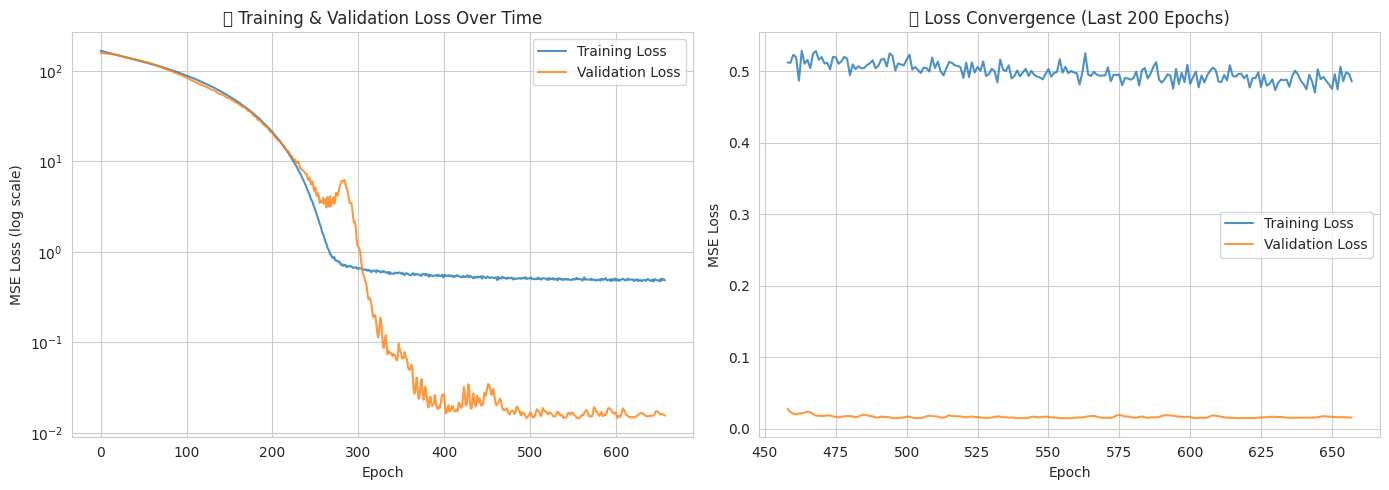


✅ Final Training Loss:   0.4854
✅ Final Validation Loss: 0.0155


In [17]:
# ============================================
# TRAINING HISTORY VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full loss curves (log scale for better visibility)
axes[0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[0].plot(val_losses,   label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('📉 Training & Validation Loss Over Time')
axes[0].legend()
axes[0].set_yscale('log')  # Log scale reveals early large drops

# Right: zoomed view of last portion of training
# Use min to handle cases where training stopped early
zoom_epochs = min(200, len(train_losses))
axes[1].plot(range(len(train_losses) - zoom_epochs, len(train_losses)),
             train_losses[-zoom_epochs:], label='Training Loss', alpha=0.8)
axes[1].plot(range(len(val_losses) - zoom_epochs, len(val_losses)),
             val_losses[-zoom_epochs:], label='Validation Loss', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title(f'🔍 Loss Convergence (Last {zoom_epochs} Epochs)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Final Training Loss:   {train_losses[-1]:.4f}")
print(f"✅ Final Validation Loss: {val_losses[-1]:.4f}")

---

# 📏 5. Model Evaluation

Now for the real test: how well does the model predict prices for houses **it has never seen**?

We evaluate on the **test set** — data that was held out from both training and validation.

## Metrics we compute

**MAE (Mean Absolute Error):** $\;\frac{1}{n}\sum|y - \hat{y}|$ — Average absolute error in dollars.

**RMSE (Root Mean Squared Error):** $\;\sqrt{\frac{1}{n}\sum(y - \hat{y})^2}$ — Penalizes large errors more heavily.

**MAPE (Mean Absolute Percentage Error):** $\;\frac{100}{n}\sum\left|\frac{y - \hat{y}}{y}\right|$ — Error as a percentage of the actual price.

**R² (Coefficient of Determination):** $\;1 - \frac{SS_{res}}{SS_{tot}}$ — How much variance in price our model explains (1.0 = perfect).


In [16]:
# ============================================
# GENERATE PREDICTIONS AND CONVERT FROM LOG SPACE
# ============================================

# 🎯🎯🎯 TODO 🎯🎯🎯
# Get predictions on the `test_features_t` variable. Remember to put
# the model in evaluation mode and to disable the gradient updates!
# Save the model prediction in the `test_predictions` variable
# Hint: don't forget to convert from log space back to real prices.
...
test_predictions = ...

# Use original (non-log) test prices for evaluation
test_prices_original = test_orig_prices

# ============================================
# OVERALL PERFORMANCE METRICS
# ============================================

# Flatten arrays for metrics calculation
actual = test_prices_original.flatten()
pred = test_predictions.flatten()

# Calculate overall metrics
# 🎯🎯🎯 TODO 🎯🎯🎯
mae = ...
rmse = ...
mape = ...

# 🎯🎯🎯 TODO 🎯🎯🎯 / Compute the R2 score
ss_res = ...
ss_tot = ...
r2_score = ...

print("=" * 55)
print("           OVERALL TEST SET PERFORMANCE")
print("=" * 55)
print()
print(f"   MAE  (Mean Absolute Error):      ${mae:,.2f}")
print(f"   RMSE (Root Mean Squared Error):  ${rmse:,.2f}")
print(f"   MAPE (Mean Absolute % Error):    {mape:.2f}%")
print(f"   R²   (Coefficient of Determination): {r2_score:.4f}")
print()
print("=" * 55)

           OVERALL TEST SET PERFORMANCE

   MAE  (Mean Absolute Error):      $19,380.77
   RMSE (Root Mean Squared Error):  $24,929.87
   MAPE (Mean Absolute % Error):    8.76%
   R²   (Coefficient of Determination): 0.9344



In [18]:
# ============================================
# PERFORMANCE BY PRICE RANGE
# ============================================

# Flatten arrays (safety)
actual = test_prices_original.flatten()
pred   = test_predictions.flatten()

# Define quartile boundaries
quartiles = np.quantile(actual, [0, 0.25, 0.5, 0.75, 1.0])

print("\n" + "=" * 55)
print("        PERFORMANCE BY PRICE RANGE (QUARTILES)")
print("=" * 55)

for i in range(4):

    # Select samples in this price range
    mask = (actual >= quartiles[i]) & (actual < quartiles[i+1])

    a = actual[mask]
    p = pred[mask]

    # Metrics
    mae_q  = np.mean(np.abs(p - a))
    rmse_q = np.sqrt(np.mean((p - a) ** 2))
    mape_q = np.mean(np.abs((p - a) / a)) * 100

    print()
    print(f"Range {i+1}: ${quartiles[i]:,.0f} → ${quartiles[i+1]:,.0f}")
    print(f"   MAE:  ${mae_q:,.2f}")
    print(f"   RMSE: ${rmse_q:,.2f}")
    print(f"   MAPE: {mape_q:.2f}%")


        PERFORMANCE BY PRICE RANGE (QUARTILES)

Range 1: $24,411 → $191,855
   MAE:  $17,202.89
   RMSE: $21,709.63
   MAPE: 14.61%

Range 2: $191,855 → $257,180
   MAE:  $17,261.97
   RMSE: $21,337.94
   MAPE: 7.71%

Range 3: $257,180 → $326,220
   MAE:  $18,421.66
   RMSE: $23,771.06
   MAPE: 6.43%

Range 4: $326,220 → $526,670
   MAE:  $24,475.96
   RMSE: $31,347.84
   MAPE: 6.28%


### Interpreting the results

- **MAE** tells you the average dollar amount the model is off by.
- **MAPE** tells you the average *percentage* error — a MAPE of 5% means the model is typically within 5% of the true price.
- **R²** close to **1.0** means the model captures most of the variance in house prices.

---

# 📊 6. Prediction Visualizations

Numbers alone don't always tell the full story. Let's create three complementary visualizations:

1. **Predicted vs Actual** scatter plot — ideally, all points should lie on the diagonal.
2. **Residuals histogram** — the distribution of errors; a narrow, centered bell-shape is ideal.
3. **Sample comparison** — a bar chart comparing actual and predicted prices for 20 random houses.

/tmp/ipykernel_6437/2827267846.py:47: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2827267846.py:47: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6437/2827267846.py:47: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


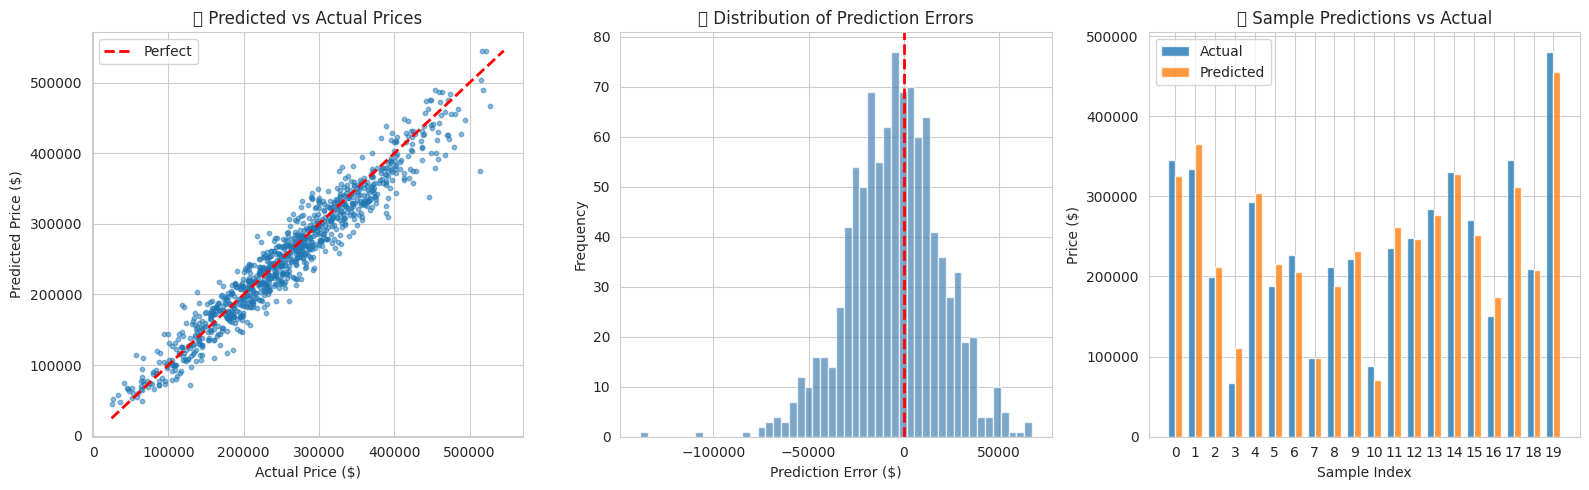

In [20]:
# @title {display-mode: "form"}
# ============================================
# PREDICTION VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Predicted vs Actual scatter ---
axes[0].scatter(test_prices_original, test_predictions,
                alpha=0.5, s=10)
# Perfect-prediction diagonal
lo = min(test_prices_original.min(), test_predictions.min())
hi = max(test_prices_original.max(), test_predictions.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('🎯 Predicted vs Actual Prices')
axes[0].legend()

# --- 2. Residuals distribution ---
residuals = (test_predictions - test_prices_original).flatten()
axes[1].hist(residuals, bins=50, color='steelblue',
             edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('📊 Distribution of Prediction Errors')

# --- 3. Sample comparison bar chart ---
np.random.seed(42)  # Reproducible random sample
sample_idx = np.random.choice(len(test_prices_original), 20,
                              replace=False)
x_pos = np.arange(20)
width = 0.35
axes[2].bar(x_pos - width / 2,
            test_prices_original[sample_idx].flatten(),
            width, label='Actual', alpha=0.8)
axes[2].bar(x_pos + width / 2,
            test_predictions[sample_idx].flatten(),
            width, label='Predicted', alpha=0.8)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Price ($)')
axes[2].set_title('🏠 Sample Predictions vs Actual')
axes[2].legend()
axes[2].set_xticks(x_pos)

plt.tight_layout()
plt.show()